# Animated scenes

Four short scenes, each showing one thing the library does while a parameter sweeps. They began as the scripts behind a demonstration reel; this notebook is the same four, with the sweeps drawn as static filmstrips so that reading it costs nothing.

Rendering them as animations is expensive — a few hundred frames each, most of the time spent in matplotlib rather than in the physics — so the stills are what this notebook draws, and the animation is left to an opt-in switch at the end.

The four are chosen to differ, and the difference is the point: the first two recompute a whole map in one broadcast call, the third re-slabs the Earth at every angle, and the fourth animates the one approximation the library makes.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

In [2]:
from matplotlib.patches import Circle

import earth
import slabs

# Indices into the flavor-ordered probability tuples: the initial
# flavor varies slowest, so with n flavors P[n*a + b] is P(nu_a -> nu_b).
P3_MUE, P3_MUMU, P4_MUS = 3, 4, 7

ACCENT, MARK, MUTED = '#1d4ed8', '#dc2626', '#94a3b8'


def vacuum_3nu(dcp=gd.DCP_NO_BF):
    return hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
        gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, dcp,
        gd.D21_NO_BF, gd.D31_NO_BF)


def vacuum_4nu(d41):
    return hamiltonians4nu.hamiltonian_4nu_vacuum_energy_independent(
        gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF,
        np.sqrt(0.10), np.sqrt(0.10), 0.0,
        gd.DCP_NO_BF, gd.D21_NO_BF, gd.D31_NO_BF, d41)

## 1. The CP phase

An oscillogram of $P_{\mu e}$ in matter, recomputed at each phase, beside the bi-probability ellipse — which is the locus traced *by* the phase, so the ellipse is drawn once and the marker says where on it the map currently sits.

Each map is 200 x 200 = 40 000 probabilities in **one** call: the Hamiltonians vary along one axis and the baselines along the other, and they broadcast.

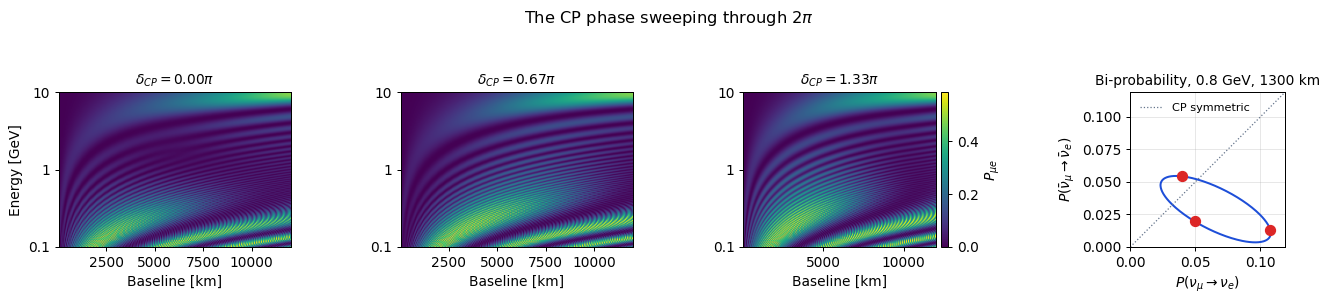

In [3]:
grid = 200
energies_cp = np.logspace(-1.0, 1.0, grid)*GEV
baselines_cp = np.linspace(50.0, 12000.0, grid)*KM


def oscillogram(dcp):
    stack = hamiltonians3nu.hamiltonian_3nu_matter(
        vacuum_3nu(dcp), energies_cp, gd.VCC_EARTH_CRUST)
    return oscprob3nu.probabilities_3nu(
        stack[:, None, :, :], baselines_cp[None, :])[:, :, P3_MUE]


def ellipse_point(dcp, energy=0.8*GEV, baseline=1300.0):
    length = baseline*KM
    # Antineutrinos need *both* changes: conjugate the vacuum
    # Hamiltonian and reverse the sign of the matter potential.
    h_nu = hamiltonians3nu.hamiltonian_3nu_matter(
        vacuum_3nu(dcp), energy, gd.VCC_EARTH_CRUST)
    h_bar = hamiltonians3nu.hamiltonian_3nu_matter(
        np.conj(vacuum_3nu(dcp)), energy, -gd.VCC_EARTH_CRUST)
    return (oscprob3nu.probabilities_3nu(h_nu, length)[P3_MUE],
            oscprob3nu.probabilities_3nu(h_bar, length)[P3_MUE])


shown = [0.0, 2.0*np.pi/3.0, 4.0*np.pi/3.0]
locus = np.array([ellipse_point(d)
                  for d in np.linspace(0.0, 2.0*np.pi, 240)])
# The colour scale is fixed over the whole sweep: taking it from
# one frame lets the others clip silently, and clipping reads as
# structure rather than as saturation.
ceiling_cp = max(float(oscillogram(d).max())
                 for d in np.linspace(0.0, 2.0*np.pi, 12,
                                      endpoint=False))

fig, axes = plt.subplots(1, 4, figsize=(15.0, 3.4),
                         gridspec_kw={'width_ratios': [1, 1, 1, 1.05]})
for ax, dcp in zip(axes[:3], shown):
    im = ax.imshow(oscillogram(dcp), origin='lower', aspect='auto',
                   cmap='viridis', vmin=0.0, vmax=ceiling_cp,
                   extent=[50.0, 12000.0, -1.0, 1.0])
    ax.set_title(r'$\delta_{CP} = %.2f\pi$' % (dcp/np.pi), fontsize=11)
    ax.set_xlabel('Baseline [km]')
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(['0.1', '1', '10'])
    ax.grid(False)
axes[0].set_ylabel('Energy [GeV]')
fig.colorbar(im, ax=axes[2], pad=0.02).set_label(r'$P_{\mu e}$')

ax = axes[3]
ax.plot(locus[:, 0], locus[:, 1], color=ACCENT, lw=1.6)
lo, hi = float(min(locus.min(), 0.0)), float(locus.max())*1.10
ax.plot([lo, hi], [lo, hi], ls=':', color='#64748b', lw=1.0,
        label='CP symmetric')
for dcp in shown:
    ax.plot(*ellipse_point(dcp), 'o', ms=8, color=MARK, zorder=5)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(r'$P(\nu_\mu \to \nu_e)$')
ax.set_ylabel(r'$P(\bar\nu_\mu \to \bar\nu_e)$')
ax.set_title('Bi-probability, 0.8 GeV, 1300 km', fontsize=11)
ax.legend(loc='upper left', fontsize=9)

fig.suptitle('The CP phase sweeping through $2\pi$', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## 2. A sterile state

Four flavors, in matter of constant density so the whole map is again one call. The sterile state feels neither the charged- nor the neutral-current potential, so $V_{NC}$ stops cancelling between the flavors and sits on the sterile entry — which is what places the resonance that moves across the frame as $\Delta m^2_{41}$ sweeps.

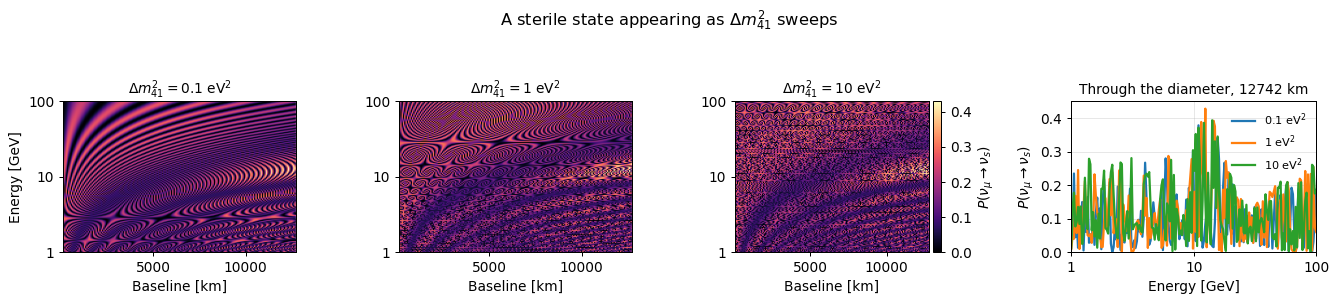

In [4]:
grid = 180
energies_s = np.logspace(0.0, 2.0, grid)*GEV
baselines_s = np.linspace(100.0, 12742.0, grid)*KM


def sterile_map(d41):
    stack = hamiltonians4nu.hamiltonian_4nu_matter(
        vacuum_4nu(d41), energies_s, gd.VCC_EARTH_CRUST,
        gd.VNC_EARTH_CRUST)
    return oscprob4nu.probabilities_4nu(
        stack[:, None, :, :], baselines_s[None, :])[:, :, P4_MUS]


splittings = [0.1, 1.0, 10.0]
maps = [sterile_map(d) for d in splittings]
ceiling_s = max(float(m.max()) for m in maps)

fig, axes = plt.subplots(1, 4, figsize=(15.0, 3.4),
                         gridspec_kw={'width_ratios': [1, 1, 1, 1.05]})
for ax, d41, m in zip(axes[:3], splittings, maps):
    im = ax.imshow(m, origin='lower', aspect='auto', cmap='magma',
                   vmin=0.0, vmax=ceiling_s,
                   extent=[100.0, 12742.0, 0.0, 2.0])
    ax.set_title(r'$\Delta m^2_{41} = %g$ eV$^2$' % d41, fontsize=11)
    ax.set_xlabel('Baseline [km]')
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['1', '10', '100'])
    ax.axvline(12742.0, color='white', lw=1.0, ls='--', alpha=0.7)
    ax.grid(False)
axes[0].set_ylabel('Energy [GeV]')
fig.colorbar(im, ax=axes[2], pad=0.02).set_label(
    r'$P(\nu_\mu\to\nu_s)$')

ax = axes[3]
for d41, m in zip(splittings, maps):
    ax.plot(np.log10(energies_s/GEV), m[:, -1],
            lw=1.8, label=r'$%g$ eV$^2$' % d41)
ax.set_xlim(0.0, 2.0)
ax.set_ylim(0.0, ceiling_s*1.05)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['1', '10', '100'])
ax.set_xlabel('Energy [GeV]')
ax.set_ylabel(r'$P(\nu_\mu \to \nu_s)$')
ax.set_title('Through the diameter, 12742 km', fontsize=11)
ax.legend(fontsize=9)

fig.suptitle('A sterile state appearing as $\Delta m^2_{41}$ sweeps',
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## 3. Through the Earth

The PREM density in cross-section with the neutrino path drawn on it, beside the survival probability along that path, as the zenith angle swings from diametric to grazing.

**This scene used to be the expensive one.** When these scripts were written `probabilities_3nu_earth` took a scalar energy — the chord, and the slabs cut from it, change with the angle — so a curve of a hundred energies was a hundred calls, and the scene said so in its own caption. Since 1.12.0 the energy may be an array, so each curve below is **one** call, with the geometry and the matter potentials built once for it rather than once per energy.

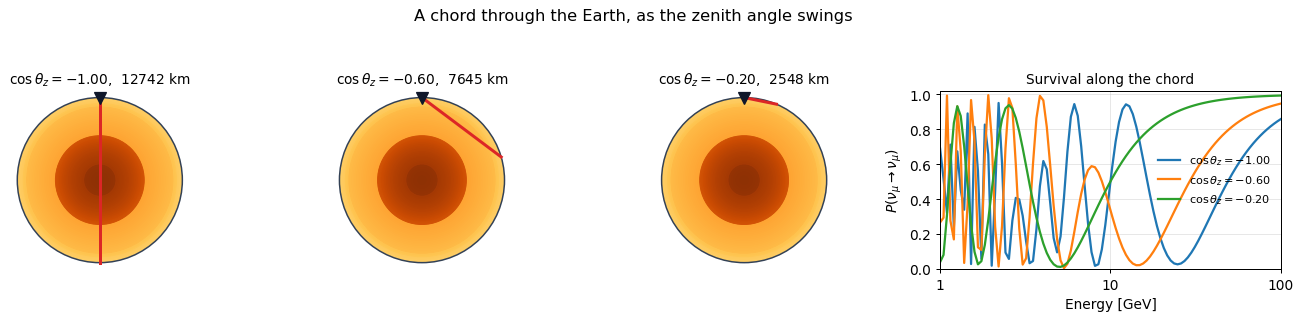

In [5]:
angles = [-1.0, -0.6, -0.2]
energies_e = np.logspace(0.0, 2.0, 100)*GEV

fig, axes = plt.subplots(1, 4, figsize=(15.0, 3.6),
                         gridspec_kw={'width_ratios': [1, 1, 1, 1.35]})

# The density disk is the same in each panel: concentric circles
# shaded by PREM, outermost first so the inner ones sit on top.
radii = np.linspace(gd.EARTH_RADIUS, 0.0, 240)
densities = earth.density_prem(radii)
colours = plt.cm.YlOrBr(0.15 + 0.75*densities/densities.max())

for ax, costhz in zip(axes[:3], angles):
    for radius, colour in zip(radii, colours):
        ax.add_patch(Circle((0.0, 0.0), radius, facecolor=colour,
                            edgecolor='none', zorder=1))
    ax.add_patch(Circle((0.0, 0.0), gd.EARTH_RADIUS, fill=False,
                        edgecolor='#334155', lw=1.2, zorder=3))
    length = earth.distance_traveled_inside_earth(costhz)
    sin_thz = np.sqrt(max(0.0, 1.0 - costhz*costhz))
    ax.plot([length*sin_thz, 0.0],
            [gd.EARTH_RADIUS + length*costhz, gd.EARTH_RADIUS],
            color=MARK, lw=2.4, zorder=4)
    ax.plot([0.0], [gd.EARTH_RADIUS], 'v', color='#0f172a', ms=9,
            zorder=5)
    span = gd.EARTH_RADIUS*1.08
    ax.set_xlim(-span, span)
    ax.set_ylim(-span, span)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(r'$\cos\theta_z = %+.2f$,  %d km'
                 % (costhz, round(length)), fontsize=11)

ax = axes[3]
for costhz in angles:
    # One call per curve: the energies are an array.
    curve = earth.probabilities_3nu_earth(
        H_VAC_3NU, energies_e, costhz)[:, P3_MUMU]
    ax.plot(np.log10(energies_e/GEV), curve, lw=1.8,
            label=r'$\cos\theta_z = %+.2f$' % costhz)
ax.set_xlim(0.0, 2.0)
ax.set_ylim(0.0, 1.02)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['1', '10', '100'])
ax.set_xlabel('Energy [GeV]')
ax.set_ylabel(r'$P(\nu_\mu \to \nu_\mu)$')
ax.set_title('Survival along the chord', fontsize=11)
ax.legend(fontsize=9)

fig.suptitle('A chord through the Earth, as the zenith angle swings',
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## 4. Cutting a profile into slabs

The one approximation the library makes. Within a slab nothing is approximated — the expansion is exact for a constant Hamiltonian — so the only question is how finely a profile that really varies is sliced, and that is the caller's to answer. The reference here is the same calculation at 600 slabs.

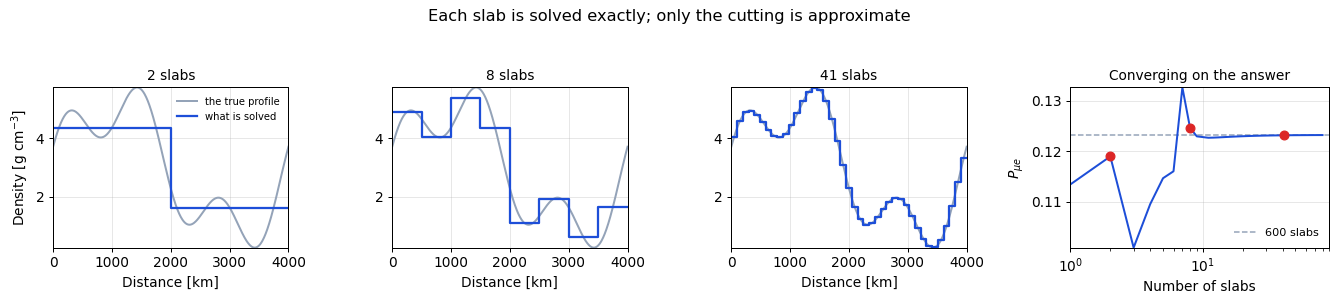

In [6]:
baseline_km, energy_s = 4000.0, 1.0*GEV
total = baseline_km*KM


def profile(x):
    """A smooth, deliberately awkward density profile [g/cm^3].

    The amplitudes sum to more than the offset, so the positivity
    of this is a property of the phase offset and the frequency
    ratio rather than of the coefficients: the two sines do not
    reach their minima together, and the measured minimum is
    0.28 g/cm^3.  A negative density would quietly reverse the
    sign of the matter potential --- the antineutrino case, and
    not what this is about --- so re-check the minimum before
    changing any of the five numbers below.
    """
    return 3.0 + 2.2*np.sin(2.0*np.pi*x/baseline_km) \
        + 1.1*np.sin(6.0*np.pi*x/baseline_km + 0.7)


def probability(n):
    edges = np.linspace(0.0, baseline_km, n + 1)
    mid = 0.5*(edges[:-1] + edges[1:])
    h = hamiltonians3nu.hamiltonian_3nu_matter(
        vacuum_3nu(), energy_s, earth.matter_potential(profile(mid)))
    return slabs.probabilities_3nu_slabs(
        h, np.full(n, total/n))[P3_MUE]


counts = np.unique(np.round(
    np.logspace(0.0, np.log10(80.0), 40)).astype(int))
values = [probability(int(n)) for n in counts]
reference = probability(600)
# Snapped to counts that were actually evaluated, so the markers
# on the trace are the same three cuts the panels draw.
shown_n = [int(counts[np.argmin(np.abs(counts - n))])
           for n in (2, 8, 40)]

fig, axes = plt.subplots(1, 4, figsize=(15.0, 3.4),
                         gridspec_kw={'width_ratios': [1, 1, 1, 1.1]})
fine = np.linspace(0.0, baseline_km, 600)
for ax, n in zip(axes[:3], shown_n):
    edges = np.linspace(0.0, baseline_km, n + 1)
    mid = 0.5*(edges[:-1] + edges[1:])
    ax.plot(fine, profile(fine), color=MUTED, lw=1.6,
            label='the true profile')
    ax.step(np.append(edges[:-1], baseline_km),
            np.append(profile(mid), profile(mid[-1])),
            where='post', color=ACCENT, lw=1.8, label='what is solved')
    ax.set_title('%d slab%s' % (n, '' if n == 1 else 's'), fontsize=11)
    ax.set_xlabel('Distance [km]')
axes[0].set_ylabel(r'Density [g cm$^{-3}$]')
axes[0].legend(loc='upper right', fontsize=8)

ax = axes[3]
ax.axhline(reference, color=MUTED, ls='--', lw=1.2, label='600 slabs')
ax.plot(counts, values, color=ACCENT, lw=1.6)
for n in shown_n:
    index = int(np.argmin(np.abs(counts - n)))
    ax.plot([counts[index]], [values[index]], 'o', ms=7, color=MARK,
            zorder=5)
ax.set_xscale('log')
ax.set_xlim(1, 90)
ax.set_xlabel('Number of slabs')
ax.set_ylabel(r'$P_{\mu e}$')
ax.set_title('Converging on the answer', fontsize=11)
ax.legend(loc='lower right', fontsize=9)

fig.suptitle('Each slab is solved exactly; only the cutting is approximate',
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Rendering them as animations

Each scene is a sweep over one parameter, so each animates directly: the panels below are redrawn frame by frame while $\delta_{CP}$, $\Delta m^2_{41}$, $\cos\theta_z$ or the slab count moves.

The stills above are what this notebook draws by default, because rendering is expensive — a few hundred frames each, and most of the time goes into matplotlib rather than into the physics. Set `RENDER = True` to write all four as GIFs. Expect several minutes and a few megabytes each. `matplotlib`'s Pillow writer is used rather than `ffmpeg`, so there is nothing to install — though the committed GIFs in `img/` went through an ffmpeg palette, which is markedly smaller.

The scenes are drawn two panels wide here, as the reel has them, rather than as the four-panel filmstrips above.

In [7]:
RENDER = False        # set True to write the four GIFs
FPS = 24

if RENDER:
    from matplotlib.animation import FuncAnimation, PillowWriter

    FIGSIZE, DPI = (11.0, 4.6), 120
    OUT = os.path.join('..', 'img')

    def caption(fig, note):
        """The standing caption, and the mutable heading."""
        fig.patch.set_facecolor('white')
        fig.text(0.5, 0.028, note, ha='center', fontsize=9.5,
                 color='#334155')
        heading = fig.suptitle('', fontsize=13)
        fig.tight_layout(rect=[0, 0.06, 1, 0.94])
        return heading

    def write(fig, update, frames, name):
        anim = FuncAnimation(fig, update, frames=frames, blit=False)
        path = os.path.join(OUT, name)
        anim.save(path, writer=PillowWriter(fps=FPS),
                  savefig_kwargs={'facecolor': 'white'})
        plt.close(fig)
        print('wrote %s (%.1f MB)'
              % (path, os.path.getsize(path)/1024.0/1024.0))

    # ---- the CP phase -------------------------------------------
    phases = np.linspace(0.0, 2.0*np.pi, 240, endpoint=False)
    fig, (ax_map, ax_ell) = plt.subplots(
        1, 2, figsize=FIGSIZE, dpi=DPI,
        gridspec_kw={'width_ratios': [1.35, 1.0]})
    image = ax_map.imshow(oscillogram(phases[0]), origin='lower',
                          aspect='auto', cmap='viridis',
                          vmin=0.0, vmax=ceiling_cp,
                          extent=[50.0, 12000.0, -1.0, 1.0])
    ax_map.set_xlabel('Baseline [km]')
    ax_map.set_ylabel('Energy [GeV]')
    ax_map.set_yticks([-1, 0, 1])
    ax_map.set_yticklabels(['0.1', '1', '10'])
    ax_map.grid(False)
    ax_ell.plot(locus[:, 0], locus[:, 1], color=ACCENT, lw=1.6)
    marker, = ax_ell.plot([], [], 'o', ms=9, color=MARK, zorder=5)
    ax_ell.set_xlim(lo, hi)
    ax_ell.set_ylim(lo, hi)
    ax_ell.set_aspect('equal', adjustable='box')
    ax_ell.set_xlabel(r'$P(\nu_\mu \to \nu_e)$')
    ax_ell.set_ylabel(r'$P(\bar\nu_\mu \to \bar\nu_e)$')
    head = caption(fig, 'One broadcast call a frame  ---  40,000 probabilities')

    def update_cp(i):
        image.set_data(oscillogram(phases[i]))
        marker.set_data(*[[v] for v in ellipse_point(phases[i])])
        head.set_text(r'The CP phase:  $\delta_{CP} = %.2f\pi$'
                      % (phases[i]/np.pi))
        return image, marker

    write(fig, update_cp, len(phases), 'anim_cp.gif')

    # ---- the sterile state ---------------------------------------
    d41s = np.logspace(-1.0, 1.0, 180)
    fig, (ax_map, ax_cut) = plt.subplots(
        1, 2, figsize=FIGSIZE, dpi=DPI,
        gridspec_kw={'width_ratios': [1.35, 1.0]})
    image = ax_map.imshow(sterile_map(d41s[0]), origin='lower',
                          aspect='auto', cmap='magma',
                          vmin=0.0, vmax=ceiling_s,
                          extent=[100.0, 12742.0, 0.0, 2.0])
    ax_map.set_xlabel('Baseline [km]')
    ax_map.set_ylabel('Energy [GeV]')
    ax_map.set_yticks([0, 1, 2])
    ax_map.set_yticklabels(['1', '10', '100'])
    ax_map.grid(False)
    curve, = ax_cut.plot([], [], color=ACCENT, lw=1.8)
    ax_cut.set_xlim(0.0, 2.0)
    ax_cut.set_ylim(0.0, ceiling_s*1.05)
    ax_cut.set_xticks([0, 1, 2])
    ax_cut.set_xticklabels(['1', '10', '100'])
    ax_cut.set_xlabel('Energy [GeV]')
    ax_cut.set_ylabel(r'$P(\nu_\mu \to \nu_s)$')
    ax_cut.set_title('Through the diameter, 12742 km', fontsize=11)
    head = caption(fig, 'Four flavors, constant density  ---  the sterile '
                        'state feels neither potential')
    axis_s = np.log10(energies_s/GEV)

    def update_sterile(i):
        now = sterile_map(d41s[i])
        image.set_data(now)
        curve.set_data(axis_s, now[:, -1])
        head.set_text(r'A sterile state:  $\Delta m^2_{41} = %.2f$ eV$^2$'
                      % d41s[i])
        return image, curve

    write(fig, update_sterile, len(d41s), 'anim_sterile.gif')

    # ---- through the Earth ---------------------------------------
    cosines = np.linspace(-1.0, -0.05, 150)
    fig, (ax_earth, ax_prob) = plt.subplots(
        1, 2, figsize=FIGSIZE, dpi=DPI,
        gridspec_kw={'width_ratios': [1.0, 1.35]})
    for radius, colour in zip(radii, colours):
        ax_earth.add_patch(Circle((0.0, 0.0), radius, facecolor=colour,
                                  edgecolor='none', zorder=1))
    ax_earth.add_patch(Circle((0.0, 0.0), gd.EARTH_RADIUS, fill=False,
                              edgecolor='#334155', lw=1.2, zorder=3))
    span = gd.EARTH_RADIUS*1.08
    ax_earth.set_xlim(-span, span)
    ax_earth.set_ylim(-span, span)
    ax_earth.set_aspect('equal')
    ax_earth.axis('off')
    ax_earth.plot([0.0], [gd.EARTH_RADIUS], 'v', color='#0f172a',
                  ms=9, zorder=5)
    path_line, = ax_earth.plot([], [], color=MARK, lw=2.2, zorder=4)
    prob_line, = ax_prob.plot([], [], color=ACCENT, lw=1.8)
    ax_prob.set_xlim(0.0, 2.0)
    ax_prob.set_ylim(0.0, 1.02)
    ax_prob.set_xticks([0, 1, 2])
    ax_prob.set_xticklabels(['1', '10', '100'])
    ax_prob.set_xlabel('Energy [GeV]')
    ax_prob.set_ylabel(r'$P(\nu_\mu \to \nu_\mu)$')
    head = caption(fig, 'The chord is re-cut into PREM slabs at every '
                        'angle  ---  100 energies, one call')
    axis_e = np.log10(energies_e/GEV)

    def update_earth(i):
        costhz = cosines[i]
        length = earth.distance_traveled_inside_earth(costhz)
        sin_thz = np.sqrt(max(0.0, 1.0 - costhz*costhz))
        path_line.set_data(
            [length*sin_thz, 0.0],
            [gd.EARTH_RADIUS + length*costhz, gd.EARTH_RADIUS])
        prob_line.set_data(axis_e, earth.probabilities_3nu_earth(
            H_VAC_3NU, energies_e, costhz)[:, P3_MUMU])
        head.set_text(r'Through the Earth:  $\cos\theta_z = %+.2f$, '
                      r'%d km' % (costhz, round(length)))
        return path_line, prob_line

    write(fig, update_earth, len(cosines), 'anim_earth.gif')

    # ---- cutting the profile -------------------------------------
    ramp = np.round(np.logspace(0.0, np.log10(80.0), 120)).astype(int)
    ramp_values = [probability(int(n)) for n in ramp]
    fig, (ax_rho, ax_conv) = plt.subplots(
        1, 2, figsize=FIGSIZE, dpi=DPI,
        gridspec_kw={'width_ratios': [1.15, 1.0]})
    ax_rho.plot(fine, profile(fine), color=MUTED, lw=1.6,
                label='the true profile')
    stair, = ax_rho.step([], [], where='post', color=ACCENT, lw=1.8,
                         label='what is solved')
    ax_rho.set_xlabel('Distance along the trajectory [km]')
    ax_rho.set_ylabel(r'Density [g cm$^{-3}$]')
    ax_rho.set_xlim(0.0, baseline_km)
    ax_rho.set_ylim(profile(fine).min()-0.3, profile(fine).max()+0.3)
    ax_rho.legend(loc='upper right', fontsize=9)
    ax_conv.axhline(reference, color=MUTED, ls='--', lw=1.2,
                    label='600 slabs')
    trace, = ax_conv.plot([], [], color=ACCENT, lw=1.6)
    dot, = ax_conv.plot([], [], 'o', ms=7, color=MARK, zorder=5)
    ax_conv.set_xscale('log')
    ax_conv.set_xlim(1, 90)
    edge = 0.12*(max(max(ramp_values), reference)
                 - min(min(ramp_values), reference)) or 0.01
    ax_conv.set_ylim(min(min(ramp_values), reference)-edge,
                     max(max(ramp_values), reference)+edge)
    ax_conv.set_xlabel('Number of slabs')
    ax_conv.set_ylabel(r'$P_{\mu e}$')
    ax_conv.legend(loc='lower right', fontsize=9)
    head = caption(fig, 'Each slab is solved exactly  ---  the only '
                        'approximation is how finely the profile is cut')

    def update_slabs(i):
        n = int(ramp[i])
        edges = np.linspace(0.0, baseline_km, n + 1)
        mid = 0.5*(edges[:-1] + edges[1:])
        stair.set_data(np.append(edges[:-1], baseline_km),
                       np.append(profile(mid), profile(mid[-1])))
        trace.set_data(ramp[:i+1], ramp_values[:i+1])
        dot.set_data([n], [ramp_values[i]])
        head.set_text(r'Layered matter:  %d slab%s,  $P_{\mu e} = %.5f$'
                      % (n, '' if n == 1 else 's', ramp_values[i]))
        return stair, trace, dot

    write(fig, update_slabs, len(ramp), 'anim_slabs.gif')

    # Pillow writes a colour table per frame, so what it just wrote is
    # some twenty times larger than it needs to be.  The same two-pass
    # palette the command line uses brings it down; skipped without
    # ffmpeg, since the GIFs are already usable.
    import shutil

    sys.path.insert(0, os.path.abspath(os.path.join('..', 'tools')))
    import make_demo_video

    if shutil.which('ffmpeg') is None:
        print('\nffmpeg not found: the GIFs above are Pillow-sized.')
    else:
        for name in ('cp', 'sterile', 'earth', 'slabs'):
            path = os.path.join(OUT, 'anim_%s.gif' % name)
            before = os.path.getsize(path)/1024.0/1024.0
            make_demo_video.shrink(path, path, fps=12,
                                   width=860, colors=128)
            after = os.path.getsize(path)/1024.0/1024.0
            print('  %-16s %5.1f MB -> %4.1f MB' % (name, before, after))
else:
    print('RENDER is False: the stills above are the output,')
    print('and img/anim_*.gif are the rendered scenes.')

RENDER is False: the stills above are the output,
and img/anim_*.gif are the rendered scenes.


### After rendering

The cell above writes the four GIFs and then shrinks them in place, through `tools/make_demo_video.py` — the same code the command line runs, so there is one implementation of the encoding rather than two.

To do either step by hand:

```shell
# Join the four scenes into one reel
python tools/make_demo_video.py --join img/anim_cp.gif \
    img/anim_sterile.gif img/anim_earth.gif img/anim_slabs.gif \
    --out ~/reel.mp4

# Shrink any clip, which is what makes a GIF publishable
python tools/make_demo_video.py --shrink ~/reel.mp4 --out ~/reel.gif
```

Both go through a **shared palette**: one pass computes a colour table for the whole clip, the second applies it. Writing a GIF directly gives every frame its own table, which is where the twenty-fold difference comes from. The knobs are `--fps`, `--width` and `--colors`, in that order of effect on size.

**Two traps, both hit while writing this.** A GIF stores its frame delays in hundredths of a second, so ffmpeg reads a 90 ms frame as roughly 100 fps and, without an explicit output rate, writes every frame nine times over — a four-hundred-frame reel became ninety megabytes and climbing before it was noticed. And `ffmpeg` installed as a **snap** has a private `/tmp` and cannot read or write under the real one; it fails naming a path that plainly exists. Work under `$HOME`.

---

**Previous:** [The evolution operator, and the SU(n) coefficients](18_evolution_operator.ipynb)  
**Next:** [An arbitrary Hamiltonian, through three profiles](20_arbitrary_hamiltonian.ipynb) --- a long-range force carried through an invented body, an exponential one, and the Earth  
[API reference](https://mbustama.github.io/NuOscProbExact/functions.html) &middot; [Numerical recipes](https://mbustama.github.io/NuOscProbExact/recipes.html) &middot; [All notebooks](.)